In [1]:
from astropy.io import fits
import h5py
import numpy as np
import os

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from astropy.coordinates import SkyCoord
import astropy.units as u

In [3]:
#### Look in the fits file
cat = 'catalogs/zall-pix-iron.fits'
hdul = fits.open(cat)
hdul.info()
data = hdul[1].data
print(data.columns.names)

Filename: catalogs/zall-pix-iron.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   ()      
  1  ZCATALOG      1 BinTableHDU    400   28425963R x 136C   [K, 7A, 6A, J, J, D, D, K, D, 10D, K, 6A, 20A, K, D, J, D, D, E, E, E, K, B, 3A, D, J, I, 8A, J, J, 4A, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, E, E, E, E, K, 2A, E, E, E, E, 1A, K, K, K, K, K, K, K, K, K, K, K, K, K, K, K, K, K, K, K, D, D, I, E, I, I, E, E, E, E, E, D, E, D, E, D, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, L, I, L, I, L, 22A]   
['TARGETID', 'SURVEY', 'PROGRAM', 'HEALPIX', 'SPGRPVAL', 'Z', 'ZERR', 'ZWARN', 'CHI2', 'COEFF', 'NPIXELS', 'SPECTYPE', 'SUBTYPE', 'NCOEFF', 'DELTACHI2', 'COADD_FIBERSTATUS', 'TARGET_RA', 'TARGET_DEC', 'PMRA', 'PMDEC', 'REF_EPOCH', 'FA_TARGET', 'FA_TYPE', 'OBJTYPE', 'SUBPRIORITY', 'OBSCONDITIONS', 'RELEASE', 'BRICKNAME', 'BRICKID', 'BRICK_OBJID', 'MORPHTYPE', '

In [3]:
LRG_DATA = data[data['DESI_TARGET'] & 1 != 0]
print("done")
ELG_DATA = data[data['DESI_TARGET'] & 2 != 0]
print("done")
QSO_DATA = data[data['DESI_TARGET'] & 4 != 0]
print("done")
scrum = 2**60
BGS_DATA = data[data['DESI_TARGET'] & (2**60) != 0]
print("done")

done
done
done


In [ ]:
print(len(data['DESI_TARGET']))
print(len(LRG_DATA))
print(len(ELG_DATA))
print(len(QSO_DATA))
print(len(BGS_DATA))

In [17]:
LRG_DATA['TARGET_RA']

array([ 44.99187684,  45.05310778,  45.32752364, ..., 276.41282498,
       276.41774525, 276.30922652], shape=(3244380,), dtype='>f8')

In [18]:
np.savez('/home/finneas/Documents/COMAP/for_finneas/catalogs/SURVEY_LRG.npz', ra=LRG_DATA['TARGET_RA'], dec=LRG_DATA['TARGET_DEC'], z=LRG_DATA['Z'])
np.savez('/home/finneas/Documents/COMAP/for_finneas/catalogs/SURVEY_ELG.npz', ra=ELG_DATA['TARGET_RA'], dec=ELG_DATA['TARGET_DEC'], z=ELG_DATA['Z'])
np.savez('/home/finneas/Documents/COMAP/for_finneas/catalogs/SURVEY_QSO.npz', ra=QSO_DATA['TARGET_RA'], dec=QSO_DATA['TARGET_DEC'], z=QSO_DATA['Z'])
np.savez('/home/finneas/Documents/COMAP/for_finneas/catalogs/SURVEY_BGS.npz', ra=BGS_DATA['TARGET_RA'], dec=BGS_DATA['TARGET_DEC'], z=BGS_DATA['Z'])

In [69]:
for i in range(1):
    if 4294967296 & 4294967296 != 0:
        print(i)

0


In [ ]:
#### Turn ra dec and z into catalogue
outfile = f'catalogs/{os.path.splitext(os.path.basename(cat))[0]}_zerr.npz'
np.savez_compressed(outfile, ra = np.array(data['TARGET_RA']), dec = np.array(data['TARGET_DEC']), z = np.array(data['Z']), zerr = np.array(data['ZERR']) )

In [4]:
observe_freq = 115

In [5]:
def trim_catalog_to_maps(outfile, cat_path, map_list, padding = 0):
    num = 0
    cat_list = []
    for h5map in map_list:
        num += 1
        ra_mins, ra_maxs = [], []
        dec_mins, dec_maxs = [], []
        freq_mins, freq_maxs = [], []
        with h5py.File(h5map, 'r') as f:
            
            ra_edges = f['ra_edges'][()] 
            dec_edges = f['dec_edges'][()]  
            freq_edges = f['freq_edges'][()]  
            ra_mins.append(ra_edges.min())
            ra_maxs.append(ra_edges.max())
            dec_mins.append(dec_edges.min())
            dec_maxs.append(dec_edges.max())
            freq_mins.append(freq_edges.min()) # We know the range is 26 - 34 already but might as well calculate it for the sake of *automation*
            freq_maxs.append(freq_edges.max())
        
        # get the bounding box of the edges
        ra_min = min(ra_mins) - padding
        ra_max = max(ra_maxs) + padding
        dec_min = min(dec_mins) - padding
        dec_max = max(dec_maxs) + padding
        z_max = (observe_freq / min(freq_mins)) - 1 # this gets converted from frequency to redshift
        z_min = (observe_freq / max(freq_maxs)) - 1

        print(f"Trimming to field {num}:")
        print(f"Bounding box: RA [{ra_min:.2f}, {ra_max:.2f}], Dec [{dec_min:.2f}, {dec_max:.2f}], Z [{z_min:.2f}, {z_max:.2f}]")
        
        # load catalogue
        cat = np.load(cat_path)
        ra_cat = cat['ra']
        dec_cat = cat['dec']
        z_cat = cat['z']
        
        # apply bounding box mask to data
        mask = (ra_cat >= ra_min) & (ra_cat <= ra_max) & (dec_cat >= dec_min) & (dec_cat <= dec_max) & (z_cat >= z_min) & (z_cat <= z_max)
        
        ra_trimmed = ra_cat[mask]
        dec_trimmed = dec_cat[mask]
        z_trimmed = z_cat[mask]

        cat_list.append({
            'ra': ra_trimmed,   
            'dec': dec_trimmed,   
            'z': z_trimmed,   
        })
        
        # Save the trimmed catalogue
        print(f"Original catalog size: {len(ra_cat)}, Trimmed size: {len(ra_trimmed)}")

    #print(cat_list)
    return combine_catalogs(outfile, cat_list, False)


In [6]:
def remove_catalog_duplicates(path_list):

    if type(path_list[0]) == str:
        cat_list = []
        for cat_path in path_list:
            cat_list.append(dict(np.load(cat_path)))
    else: # Just use the path list if it already contains the catalog objects / dicts
        cat_list = path_list
    
    # iterate through each catalog pair
    for i in range(len(cat_list)):
        for j in range(i+1, len(cat_list)):
            cat_a = cat_list[i]
            cat_b = cat_list[j]
            skycoord_a = SkyCoord(ra=cat_a['ra']*u.degree, dec=cat_a['dec']*u.degree)
            skycoord_b = SkyCoord(ra=cat_b['ra']*u.degree, dec=cat_b['dec']*u.degree)
            
            idx, sep2d, d3d = skycoord_a.match_to_catalog_sky(skycoord_b)
            z_diff = np.abs(cat_a['z'] - cat_b['z'][idx])
            # threshold
            mask = (sep2d < 5*u.arcsec) & (z_diff < 0.001)
            print(f"{np.count_nonzero(mask)} of {len(cat_a['ra'])} objects in catalog {i} are potential duplicates of catalog {j}")
    
            # remove potential duplicates
            cat_a['ra'] = cat_a['ra'][~mask]
            cat_a['dec'] = cat_a['dec'][~mask]
            cat_a['z'] = cat_a['z'][~mask]

    return cat_list

In [7]:
def combine_catalogs(outfile, path_list, remove_duplicates=True):

    if remove_duplicates:
        cat_list = remove_catalog_duplicates(path_list)
    else:
        if type(path_list[0]) == str:
            cat_list = []
            for cat_path in path_list:
                cat_list.append(dict(np.load(cat_path)))
        else: # Just use the path list if it already contains the catalog objects / dicts
            cat_list = path_list
    
    combo_ra = np.array([])
    combo_dec = np.array([])
    combo_z = np.array([])
    
    for cat in cat_list:
        
        combo_ra = np.append(combo_ra, cat['ra'])
        combo_dec = np.append(combo_dec, cat['dec'])
        combo_z = np.append(combo_z, cat['z'])

    if outfile != None:
        np.savez(outfile, ra=combo_ra, dec=combo_dec, z=combo_z)

    print('done!')
    return {
        'ra': combo_ra,
        'dec': combo_dec,
        'z': combo_z,
    }

In [6]:
# make a fake catalog
num_objects = 500
a_ra = np.random.uniform(0, 150, num_objects);
a_dec = np.random.uniform(0, 60, num_objects);
a_z = np.random.uniform(1, 4, num_objects);

b_ra = np.random.uniform(0, 150, num_objects);
b_dec = np.random.uniform(0, 60, num_objects);
b_z = np.random.uniform(1, 4, num_objects);

dup_ra = np.random.uniform(175, 350, num_objects);
dup_dec = np.random.uniform(0, 60, num_objects);
dup_z = np.random.uniform(1, 4, num_objects);

n_ra =  (np.random.uniform(-5, 5, num_objects) * u.arcsec).to_value(u.deg)
n_dec = (np.random.uniform(-5, 5, num_objects) * u.arcsec).to_value(u.deg)
n_z = np.random.uniform(-0.001, 0.001, num_objects)

np.savez('catalogs/duplicate_test_a.npz', ra=np.concatenate((a_ra, dup_ra), axis=0), dec=np.concatenate((a_dec, dup_dec), axis=0), z=np.concatenate((a_z, dup_z), axis=0))
np.savez('catalogs/duplicate_test_b.npz', ra=np.concatenate((b_ra, dup_ra+n_ra), axis=0), dec=np.concatenate((b_dec, dup_dec+n_dec), axis=0), z=np.concatenate((b_z, dup_z+n_z), axis=0))


### Random Checks

In [98]:
bungbung = np.load('/home/finneas/Documents/COMAP/for_finneas/catalogs/QSO_cat_iron_cumulative_v0.npz')

In [101]:
bungbung['ra']

array([ 24.02481011,  23.97313777,  23.9672614 , ..., 290.65314458,
       290.75696252, 288.96294866], shape=(2182309,), dtype='>f8')

In [11]:
# map file paths
h5_files = ['/home/finneas/Documents/COMAP/for_finneas/comap_data/co2_s12_v5_take6_n5_subtr_exper.h5',
            '/home/finneas/Documents/COMAP/for_finneas/comap_data/co6_s12_v5_take6_n5_subtr_exper.h5',
            '/home/finneas/Documents/COMAP/for_finneas/comap_data/co7_s12_v5_take6_n5_subtr_exper.h5']

In [51]:
(1 * u.arcsec).to(u.deg) / u.deg

<Quantity 0.00027778>

In [8]:
path_list = [
    'catalogs/hetdex_5.0.0_erincuts250421_no_false_positives.npz',
    'catalogs/allz_ourfields_5.0.1.npz',
    #'catalogs/QSO_cat_iron_cumulative_v0.npz',
    #'catalogs/zall-pix-iron_starless.npz'
]

In [16]:
for path in path_list:
    trim_catalog_to_maps(None, path, h5_files)

Trimming to field 1:
Bounding box: RA [23.44, 27.43], Dec [-2.00, 2.00], Z [2.38, 3.42]
Original catalog size: 10455, Trimmed size: 4630
Trimming to field 2:
Bounding box: RA [222.51, 229.49], Dec [53.00, 57.00], Z [2.38, 3.42]
Original catalog size: 10455, Trimmed size: 0
Trimming to field 3:
Bounding box: RA [166.71, 173.29], Dec [50.50, 54.50], Z [2.38, 3.42]
Original catalog size: 10455, Trimmed size: 5825
done!
Trimming to field 1:
Bounding box: RA [23.44, 27.43], Dec [-2.00, 2.00], Z [2.38, 3.42]
Original catalog size: 34739, Trimmed size: 5606
Trimming to field 2:
Bounding box: RA [222.51, 229.49], Dec [53.00, 57.00], Z [2.38, 3.42]
Original catalog size: 34739, Trimmed size: 593
Trimming to field 3:
Bounding box: RA [166.71, 173.29], Dec [50.50, 54.50], Z [2.38, 3.42]
Original catalog size: 34739, Trimmed size: 7253
done!
Trimming to field 1:
Bounding box: RA [23.44, 27.43], Dec [-2.00, 2.00], Z [2.38, 3.42]
Original catalog size: 2182309, Trimmed size: 905
Trimming to field 2:

In [31]:

trim_catalog_to_maps('/home/finneas/Documents/COMAP/for_finneas/catalogs/SURVEY_QSO_trimmed.npz', '/home/finneas/Documents/COMAP/for_finneas/catalogs/QSO_cat_iron_cumulative_v0.npz', h5_files, 0)
trim_catalog_to_maps('/home/finneas/Documents/COMAP/for_finneas/catalogs/SURVEY_QSO2222_trimmed.npz', '/home/finneas/Documents/COMAP/for_finneas/catalogs/SURVEY_QSO.npz', h5_files, 0)

Trimming to field 1:
Bounding box: RA [23.44, 27.43], Dec [-2.00, 2.00], Z [2.38, 3.42]
Original catalog size: 2182309, Trimmed size: 905
Trimming to field 2:
Bounding box: RA [222.51, 229.49], Dec [53.00, 57.00], Z [2.38, 3.42]
Original catalog size: 2182309, Trimmed size: 1
Trimming to field 3:
Bounding box: RA [166.71, 173.29], Dec [50.50, 54.50], Z [2.38, 3.42]
Original catalog size: 2182309, Trimmed size: 184
done!
Trimming to field 1:
Bounding box: RA [23.44, 27.43], Dec [-2.00, 2.00], Z [2.38, 3.42]
Original catalog size: 2270430, Trimmed size: 514
Trimming to field 2:
Bounding box: RA [222.51, 229.49], Dec [53.00, 57.00], Z [2.38, 3.42]
Original catalog size: 2270430, Trimmed size: 1
Trimming to field 3:
Bounding box: RA [166.71, 173.29], Dec [50.50, 54.50], Z [2.38, 3.42]
Original catalog size: 2270430, Trimmed size: 5
done!


{'ra': array([ 26.58323689,  25.76313044,  25.94954291,  24.37478339,
         25.56145182,  24.72831677,  23.52195725,  23.64450623,
         23.70951023,  23.83083436,  23.94818219,  23.65915287,
         23.68044888,  23.75748669,  24.03884992,  24.1362948 ,
         24.17207881,  24.20595385,  24.29018278,  23.47392492,
         23.57850747,  23.7307537 ,  23.75960031,  23.80087721,
         24.06755871,  23.94989349,  23.49143298,  23.6311992 ,
         23.74600419,  23.45129613,  23.56411672,  25.97840604,
         26.26580827,  27.18494559,  26.10517703,  26.17415571,
         26.18802391,  26.23937096,  26.2694008 ,  26.76831677,
         26.83100178,  26.86932887,  26.71218069,  26.83349082,
         27.23049509,  27.33894159,  27.41875488,  26.90289137,
         27.03793849,  27.09964295,  27.16679284,  27.19567093,
         27.37479008,  26.9139159 ,  27.1226507 ,  27.26414747,
         27.34241469,  27.17572203,  25.3356695 ,  25.44966964,
         25.46721153,  25.74975315

In [12]:
# the other two catalogs are already trimmed
cat1 = trim_catalog_to_maps(None, 'catalogs/hetdex_5.0.0_erincuts250421_no_false_positives.npz', h5_files, 0)
cat2 = trim_catalog_to_maps(None, 'catalogs/allz_ourfields_5.0.1.npz', h5_files, 0)
    
# combine them all
catts = [dict(np.load('catalogs/allz_ourfields_5.0.1.npz')), dict(np.load('catalogs/hetdex_5.0.0_erincuts250421_no_false_positives.npz'))]
dud = combine_catalogs('catalogs/combined_HETDEX_noduplicates.npz', catts, remove_duplicates=True)
#print(sum(len(d['z']) for d in catts))
#print(len(dud['z']))


Trimming to field 1:
Bounding box: RA [23.44, 27.43], Dec [-2.00, 2.00], Z [2.38, 3.42]
Original catalog size: 10455, Trimmed size: 4630
Trimming to field 2:
Bounding box: RA [222.51, 229.49], Dec [53.00, 57.00], Z [2.38, 3.42]
Original catalog size: 10455, Trimmed size: 0
Trimming to field 3:
Bounding box: RA [166.71, 173.29], Dec [50.50, 54.50], Z [2.38, 3.42]
Original catalog size: 10455, Trimmed size: 5825
done!
Trimming to field 1:
Bounding box: RA [23.44, 27.43], Dec [-2.00, 2.00], Z [2.38, 3.42]
Original catalog size: 34739, Trimmed size: 5606
Trimming to field 2:
Bounding box: RA [222.51, 229.49], Dec [53.00, 57.00], Z [2.38, 3.42]
Original catalog size: 34739, Trimmed size: 593
Trimming to field 3:
Bounding box: RA [166.71, 173.29], Dec [50.50, 54.50], Z [2.38, 3.42]
Original catalog size: 34739, Trimmed size: 7253
done!
10457 of 34739 objects in catalog 0 are potential duplicates of catalog 1
done!


2270430


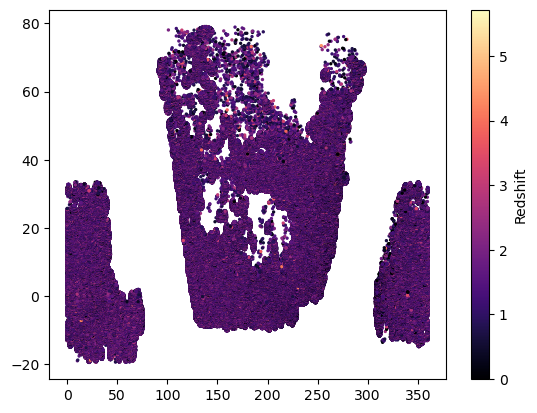

In [3]:
test = np.load('/home/finneas/Documents/COMAP/for_finneas/catalogs/SURVEY_QSO.npz')
print(len(test['z']))
scatter = plt.scatter(test['ra'], test['dec'], c=test['z'], cmap='magma', s=2)
plt.colorbar(scatter, label="Redshift")
plt.show()

2182309


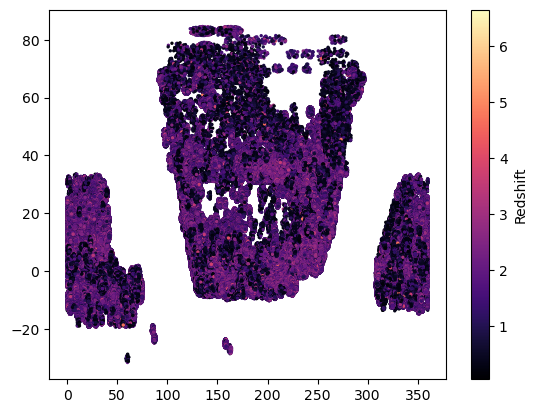

In [4]:
test = np.load('/home/finneas/Documents/COMAP/for_finneas/catalogs/QSO_cat_iron_cumulative_v0.npz')
print(len(test['z']))
scatter = plt.scatter(test['ra'], test['dec'], c=test['z'], cmap='magma', s=2)
plt.colorbar(scatter, label="Redshift")
plt.show()

494 of 1000 objects in catalog 0 are potential duplicates of catalog 1
506


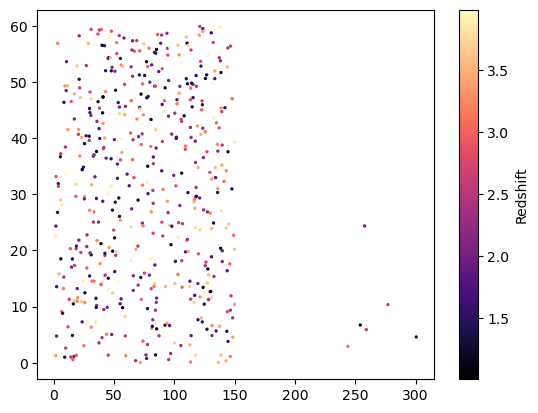

In [67]:
test = remove_catalog_duplicates(['catalogs/duplicate_test_a.npz','catalogs/duplicate_test_b.npz'])[0]
print(len(test['z']))
scatter = plt.scatter(test['ra'], test['dec'], c=test['z'], cmap='magma', s=2)
plt.colorbar(scatter, label="Redshift")
plt.show()

In [35]:
test = combine_catalogs('catalogs/BONG.npz', catts, remove_duplicates=False)
print(len(test['z']))
scatter = plt.scatter(test['ra'], test['dec'], c=test['z'], cmap='magma', s=2)
plt.colorbar(scatter, label="Redshift")
#plt.xlim(0,360)
#plt.ylim(-30,90)
#plt.hist(test['z'], bins=1000)
plt.show()

NameError: name 'catts' is not defined

2182309


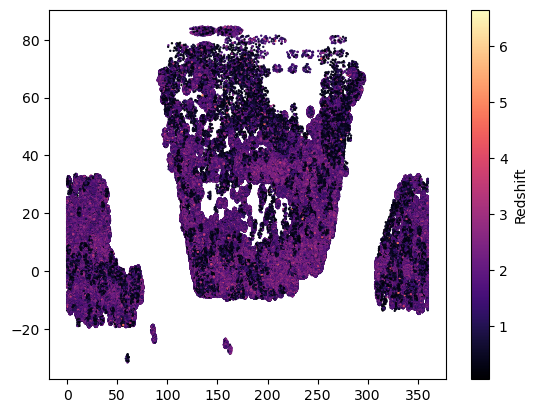

In [69]:
test = np.load('catalogs/QSO_cat_iron_cumulative_v0.npz')
print(len(test['z']))
scatter = plt.scatter(test['ra'], test['dec'], c=test['z'], cmap='magma', s=0.5)
plt.colorbar(scatter, label="Redshift")
#plt.xlim(0,360)
#plt.ylim(-30,90)
#plt.hist(test['z'], bins=1000)
plt.show()

In [2]:
test = np.load('catalogs/combined_catalog.npz')
#scatter = plt.scatter(test['ra'], test['dec'], c=test['z'], cmap='magma', s=0.5)
#plt.colorbar(scatter, label="Redshift")
#plt.show()

In [4]:
len(test['ra'])

35659

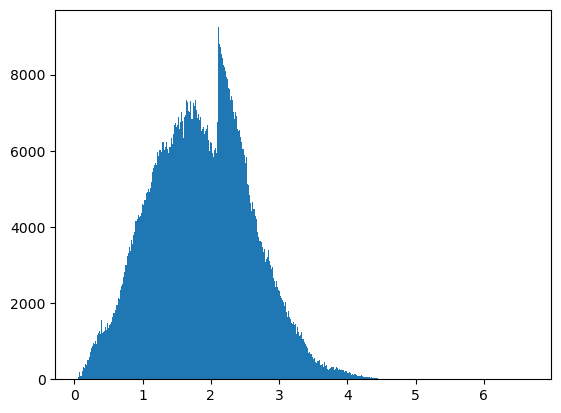

In [2]:
test = np.load('catalogs/QSO_cat_iron_cumulative_v0.npz')
plt.hist(test['z'], bins=1000)
plt.show()

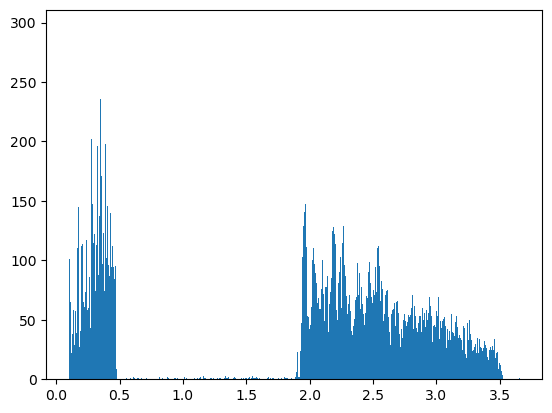

In [14]:
test = np.load('catalogs/combined_catalog_sans-zall.npz')
plt.hist(test['z'], bins=1000)
plt.show()

35659


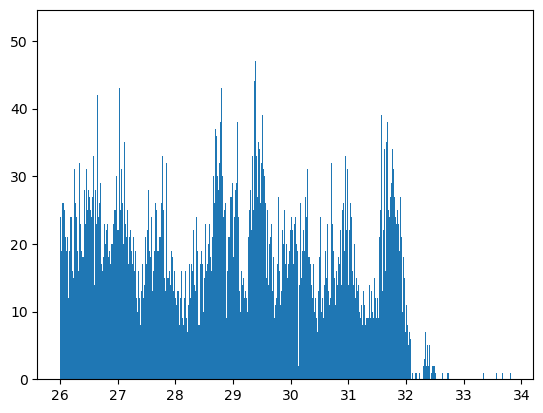

In [32]:
test = np.load('catalogs/combined_catalog.npz')
mask = (test['z'] >= 1.76176470588) & (test['z'] <= 2.61153846154)
print(len(test['z']))
plt.hist(93.9 / (test['z'][mask]+1), bins=1000)
#plt.xlim(0, 0.001)
plt.show()

In [140]:
test['z'][test['z'] > 0.005]

array([0.80420576, 0.93275248, 0.39072327, ..., 0.22080053, 0.81840676,
       0.6332302 ], shape=(23404440,), dtype='>f8')

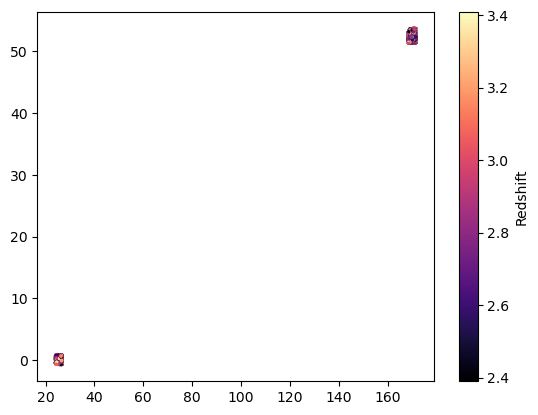

In [44]:
test = np.load('catalogs/hetdex_5.0.0_erincuts250421_no_false_positives.npz')
scatter = plt.scatter(test['ra'], test['dec'], c=test['z'], cmap='magma', s=2)
plt.colorbar(scatter, label="Redshift")
plt.show()

15280


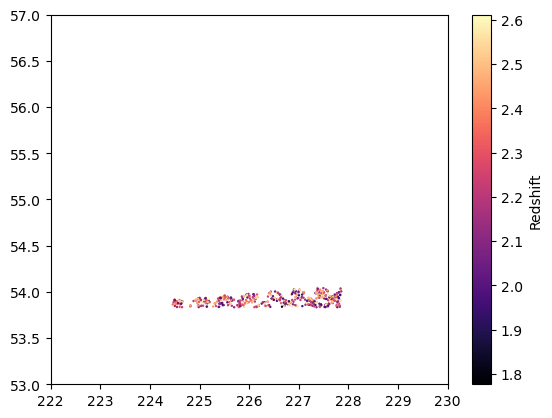

In [30]:
test = np.load('catalogs/combined_catalog.npz')
mask = (test['z'] >= 1.76176470588) & (test['z'] <= 2.61153846154)
print(len(test['z'][mask]))
scatter = plt.scatter(test['ra'][mask], test['dec'][mask], c=test['z'][mask], cmap='magma', s=0.5)
plt.colorbar(scatter, label="Redshift")
#plt.xlim(20,30)
#plt.ylim(-3,3)

#plt.xlim(165,175)
#plt.ylim(50,55)

plt.xlim(222,230)
plt.ylim(53,57)

plt.show()

In [152]:
bogem = np.load('catalogs/zall-pix-iron_zerr.npz')
bogem['zerr'][:100]

array([9.58900443e-06, 8.06674507e-07, 2.23214610e-46, 2.03138068e-05,
       7.59130673e-05, 5.00538026e-05, 3.68932530e-05, 1.17566510e-04,
       4.97474244e-05, 6.19489751e-05, 2.23214610e-46, 9.85344039e-06,
       8.96094694e-06, 7.99283043e-04, 1.09995270e-04, 1.42072291e-04,
       1.43445373e-04, 3.44823404e-04, 3.27114490e-05, 7.87248138e-05,
       1.72460548e-04, 8.22339189e-05, 7.97615572e-05, 1.54021945e-04,
       4.48198873e-06, 4.75319207e-06, 1.51574028e-05, 3.31323582e-04,
       1.57310700e-05, 2.23214610e-46, 4.38610685e-05, 7.95798726e-06,
       2.17740053e-05, 1.29642014e-04, 1.37083212e-06, 4.44066117e-04,
       9.32315672e-05, 2.23236871e-04, 1.14857757e-05, 1.19017215e-04,
       4.30345147e-05, 1.79205816e-04, 1.32737306e-06, 7.86914306e-06,
       2.85275573e-04, 2.37374834e-05, 2.06059050e-05, 2.23214610e-46,
       2.23214610e-46, 3.19244742e-05, 3.11221724e-04, 1.28387308e-04,
       6.98654624e-07, 9.87147545e-05, 2.31103560e-04, 5.34185418e-05,
      

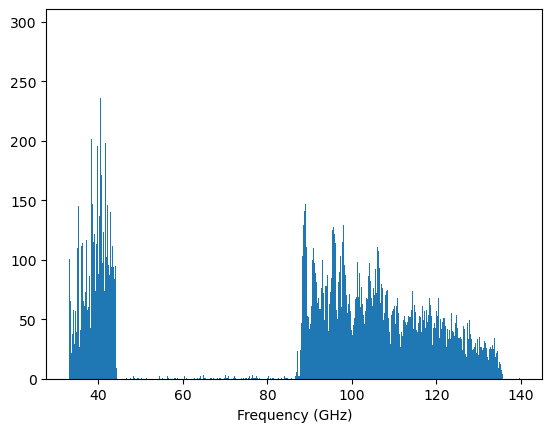

In [11]:
test = np.load('catalogs/combined_catalog.npz')

bung = []
for i in range(len(test['z'])):
    bung.append((30*test['z'][i])+30)

plt.hist(bung, bins=1000)
plt.xlabel('Frequency (GHz)')
plt.show()

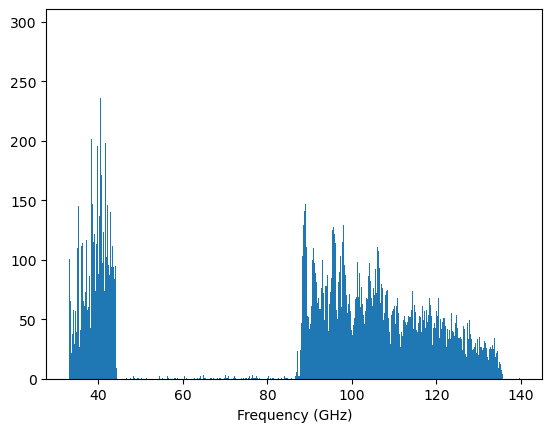

In [13]:
plt.hist(bung, bins=1000)
plt.xlabel('Frequency (GHz)')
plt.savefig('scrocococococ.png')
plt.show()